In [1]:
import skrf as rf

from pmrf.models.lines import PhysicalCoaxial
from pmrf.parameter import norm, uniform, fixed
from pmrf.fitting import ScipyFitter
from pmrf._features import FeatureExtractor
from pmrf._modifiers import ModifierChain

# Create the model
coax = PhysicalCoaxial(name='coax')

wa, wb = 0.8, 1.2
params = {
    'din': uniform(1.12e-3*wa, 1.12e-3*wb),
    'dout': uniform(3.2e-3*wa, 3.2e-3*wb),
    'length': uniform(10*wa, 10*wb),
    'epr': uniform(1.45*wa, 1.45*wb),
    'tand': uniform(0.0, 0.1),
    'rho': uniform(1.6e-8*wa, 1.6e-8*wb),
}

measured = rf.Network('../examples/data/10m_cable.s2p', f_unit='MHz')

# Initialize the fitter
fitter = ScipyFitter(
    model=coax,
    measured=measured,
    params=params,
    features=[FeatureExtractor(ports=(0, 0)), FeatureExtractor(ports=(0, 1)), FeatureExtractor(ports=(1, 0)), FeatureExtractor(ports=(1, 1))],
)

# Run the fit
fitter.fit()

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 70.54110074549033
             x: [ 1.340e-03  2.573e-03  8.040e+00  1.734e+00  9.900e-02
                  1.914e-08  1.000e+00]
           nit: 79
          nfev: 110
 final_simplex: (array([[ 1.340e-03,  2.573e-03, ...,  1.914e-08,
                         1.000e+00],
                       [ 1.340e-03,  2.573e-03, ...,  1.914e-08,
                         1.000e+00],
                       ...,
                       [ 1.340e-03,  2.573e-03, ...,  1.914e-08,
                         1.000e+00],
                       [ 1.340e-03,  2.573e-03, ...,  1.914e-08,
                         1.000e+00]]), array([ 7.054e+01,  7.054e+01,  7.054e+01,  7.054e+01,
                        7.054e+01,  7.054e+01,  7.054e+01,  7.054e+01]))

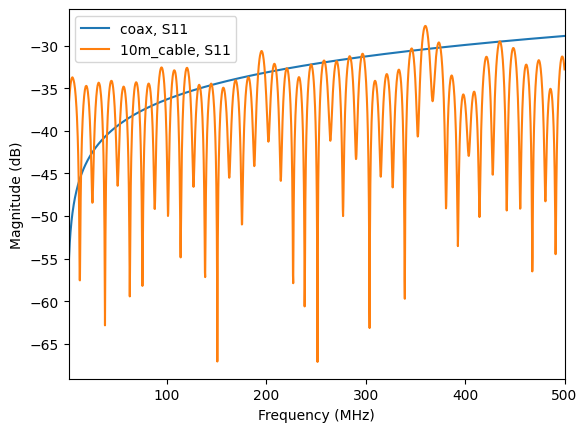

In [2]:
import matplotlib.pyplot as plt

plt.figure()
fitter.model.to_skrf(measured.frequency).plot_s_db(m=0, n=0)
measured.plot_s_db(m=0, n=0)